In [2]:
import gc
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from safetensors.torch import load_file
import torch
import seaborn as sns
import numpy as np

In [3]:
main_path = '/home/jayje/shared_space/lorahub_weights/hf_expert_single_merge_init0_leakyrelu/'
exp_folders = os.listdir(main_path)

In [4]:
d = {}
for exp_folder in exp_folders:
    task_name = exp_folder.split('lr5e-2_')[-1]
    exp_name = exp_folder.split('_lr5e-2_')[0].split('lorahub_hf_expert_single_merge_')[-1]
    if task_name not in d:
        d[task_name] = {}
    try:
        with open(f"{main_path}/{exp_folder}/job_summary.json", "r") as f:
            tmp = json.load(f)
            d[task_name][exp_name] = tmp['test/exact_string_match_accuracy']
    except:
        print(f"Failed to open {exp_folder} job summary")

Failed to open lorahub_hf_expert_single_merge_prxy5608---5de747e3-5418-48df-9d53-3769599cfbcf_lr5e-2_machine_paraphrase_dataset job summary
Failed to open lorahub_hf_expert_single_merge_jesie---model_dv3mq_mv11_850_lr5e-2_typescript_chunks job summary
Failed to open lorahub_hf_expert_single_merge_npark95---qlora_llama3_0shot_lr5e-2_typescript_chunks job summary
Failed to open lorahub_hf_expert_single_merge_Krisbiantoro---orpo_llm_botika_140824_peft_lr5e-2_cryptonews_articles job summary
Failed to open lorahub_hf_expert_single_merge_avyavkumar---llama-3.1-language-identification_lr5e-2_machine_paraphrase_dataset job summary
Failed to open lorahub_hf_expert_single_merge_clembench-playpen---meta-llama-Meta-Llama-3.1-8B-Instruct_SFT_E2_D50005_lr5e-2_machine_paraphrase_dataset job summary
Failed to open lorahub_hf_expert_single_merge_Krisbiantoro---orpo_llm_botika_140824_peft_lr5e-2_ade_corpus_v2 job summary
Failed to open lorahub_hf_expert_single_merge_LangAGI-Lab---Meta-Llama-3.1-8B-Instr

In [5]:
df = pd.DataFrame(d).T

In [6]:
df.head()

,Hiranmai49---Llama-3.1-8B-Instruct-contracts-ContinuedPretrainingLlama3.18b,lhong4759---ac11856d-78c8-4956-9dd4-f2022250559f,ErrorAI---2755f43c-ba1a-457a-9bc2-784d5addb9f8,GaetanMichelet---Llama-31-8B_task-1_120-samples_config-2,LangAGI-Lab---Meta-Llama-3.1-8B-Instruct-WM-acctree-16k-75-adapter-new,nhung01---6bd6ed7e-3782-48cf-a353-85d3c4794a1b,Shibyan---llama3.1_Odata2SQL-lora,GaetanMichelet---Llama-31-8B_task-2_120-samples_config-2_auto,GaetanMichelet---Llama-31-8B_task-2_60-samples_config-3,arshiakarimian1---spam-llama3.1-8B-teacher-all,...,RAG-Gym---Search-o1-MedQA-SFT,LangAGI-Lab---Meta-Llama-3.1-8B-Instruct-RM-16k-adapter,RAG-Gym---Direct-HotpotQA-SFT,chano12---llama_memory_selection_inden,ai-law-society-lab---oral-args-llama8b-finetuned,cunghoctienganh---066e5c46-91d2-43b1-b143-5210fa6b0075,aravind-selvam---Llams_3.1_8B_instruct_behaviour_cloning_all_data_exp_1_4bit_old_answerer_prompt,nvidia---llama-3.1-nemoguard-8b-topic-control,pejho---llama381binstruct_summarize_short,GaetanMichelet---Llama-31-8B_task-1_60-samples_config-2_auto
clinc_oos,0.211200,0.235800,0.161400,0.157600,0.152800,0.182800,0.152200,0.146800,0.172400,0.183400,...,0.130800,0.166000,0.146000,0.197400,0.198000,0.179400,0.239000,0.156200,0.176200,0.129400
tweet_topic_single,0.756987,0.720800,0.690203,0.692557,0.664313,0.713739,0.654898,0.727273,0.619594,0.661371,...,0.594587,0.640188,0.711091,0.725213,0.710209,0.680200,0.750809,0.687261,0.688732,0.703442
object_counting,0.377424,0.373961,0.368421,0.303324,0.407202,0.371884,0.316482,0.406510,0.318560,0.396122,...,0.328947,0.331717,0.395429,0.405125,0.363573,0.342105,0.439751,0.295014,0.380886,0.310942
twitter_financial_news_sentiment,0.514136,0.726702,0.496335,0.451309,0.741361,0.383246,0.330890,0.356021,0.361257,0.427225,...,0.358115,0.469110,0.402094,0.475393,0.673298,0.351832,0.753927,0.563351,0.502618,0.339267
glue_qqp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
zero_shot = pd.read_csv("/home/jayje/scratch/code/moose/results/tables/zero_shot_performance.csv")

In [8]:
df.head()

,Hiranmai49---Llama-3.1-8B-Instruct-contracts-ContinuedPretrainingLlama3.18b,lhong4759---ac11856d-78c8-4956-9dd4-f2022250559f,ErrorAI---2755f43c-ba1a-457a-9bc2-784d5addb9f8,GaetanMichelet---Llama-31-8B_task-1_120-samples_config-2,LangAGI-Lab---Meta-Llama-3.1-8B-Instruct-WM-acctree-16k-75-adapter-new,nhung01---6bd6ed7e-3782-48cf-a353-85d3c4794a1b,Shibyan---llama3.1_Odata2SQL-lora,GaetanMichelet---Llama-31-8B_task-2_120-samples_config-2_auto,GaetanMichelet---Llama-31-8B_task-2_60-samples_config-3,arshiakarimian1---spam-llama3.1-8B-teacher-all,...,RAG-Gym---Search-o1-MedQA-SFT,LangAGI-Lab---Meta-Llama-3.1-8B-Instruct-RM-16k-adapter,RAG-Gym---Direct-HotpotQA-SFT,chano12---llama_memory_selection_inden,ai-law-society-lab---oral-args-llama8b-finetuned,cunghoctienganh---066e5c46-91d2-43b1-b143-5210fa6b0075,aravind-selvam---Llams_3.1_8B_instruct_behaviour_cloning_all_data_exp_1_4bit_old_answerer_prompt,nvidia---llama-3.1-nemoguard-8b-topic-control,pejho---llama381binstruct_summarize_short,GaetanMichelet---Llama-31-8B_task-1_60-samples_config-2_auto
clinc_oos,0.211200,0.235800,0.161400,0.157600,0.152800,0.182800,0.152200,0.146800,0.172400,0.183400,...,0.130800,0.166000,0.146000,0.197400,0.198000,0.179400,0.239000,0.156200,0.176200,0.129400
tweet_topic_single,0.756987,0.720800,0.690203,0.692557,0.664313,0.713739,0.654898,0.727273,0.619594,0.661371,...,0.594587,0.640188,0.711091,0.725213,0.710209,0.680200,0.750809,0.687261,0.688732,0.703442
object_counting,0.377424,0.373961,0.368421,0.303324,0.407202,0.371884,0.316482,0.406510,0.318560,0.396122,...,0.328947,0.331717,0.395429,0.405125,0.363573,0.342105,0.439751,0.295014,0.380886,0.310942
twitter_financial_news_sentiment,0.514136,0.726702,0.496335,0.451309,0.741361,0.383246,0.330890,0.356021,0.361257,0.427225,...,0.358115,0.469110,0.402094,0.475393,0.673298,0.351832,0.753927,0.563351,0.502618,0.339267
glue_qqp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df_fin = df.join(
    zero_shot.set_index('task')
)
for c in df_fin.columns:
    if c != 'zero_shot':
        df_fin[c] = (df_fin[c] - df_fin['zero_shot']) / df_fin['zero_shot']

In [11]:
df_fin

,Hiranmai49---Llama-3.1-8B-Instruct-contracts-ContinuedPretrainingLlama3.18b,lhong4759---ac11856d-78c8-4956-9dd4-f2022250559f,ErrorAI---2755f43c-ba1a-457a-9bc2-784d5addb9f8,GaetanMichelet---Llama-31-8B_task-1_120-samples_config-2,LangAGI-Lab---Meta-Llama-3.1-8B-Instruct-WM-acctree-16k-75-adapter-new,nhung01---6bd6ed7e-3782-48cf-a353-85d3c4794a1b,Shibyan---llama3.1_Odata2SQL-lora,GaetanMichelet---Llama-31-8B_task-2_120-samples_config-2_auto,GaetanMichelet---Llama-31-8B_task-2_60-samples_config-3,arshiakarimian1---spam-llama3.1-8B-teacher-all,...,LangAGI-Lab---Meta-Llama-3.1-8B-Instruct-RM-16k-adapter,RAG-Gym---Direct-HotpotQA-SFT,chano12---llama_memory_selection_inden,ai-law-society-lab---oral-args-llama8b-finetuned,cunghoctienganh---066e5c46-91d2-43b1-b143-5210fa6b0075,aravind-selvam---Llams_3.1_8B_instruct_behaviour_cloning_all_data_exp_1_4bit_old_answerer_prompt,nvidia---llama-3.1-nemoguard-8b-topic-control,pejho---llama381binstruct_summarize_short,GaetanMichelet---Llama-31-8B_task-1_60-samples_config-2_auto,zero_shot
clinc_oos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tweet_topic_single,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
object_counting,0.322813,0.310678,0.291260,0.063105,0.427182,0.303396,0.109222,0.424755,0.116503,0.388347,...,0.162620,0.385920,0.419901,0.274270,0.199027,0.541260,0.033979,0.334949,0.089804,0.285319
twitter_financial_news_sentiment,0.427327,1.017444,0.377909,0.252908,1.058142,0.063955,-0.081394,-0.011627,0.002908,0.186048,...,0.302327,0.116280,0.319769,0.869188,-0.023255,1.093026,0.563955,0.395350,-0.058138,0.360209
glue_qqp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.784600
typescript_chunks,0.181158,0.133049,0.168379,0.127537,0.153094,0.148083,0.106490,0.153596,0.110248,0.177149,...,0.118517,0.176647,0.197194,0.167126,0.119519,0.165122,0.140065,0.168128,0.141569,0.798200
cryptonews_articles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
banking77,0.038547,0.058371,0.026432,-0.037444,0.004406,-0.029735,-0.046255,-0.089206,-0.025330,0.074891,...,-0.082599,-0.124449,0.004406,0.014318,-0.005506,0.185023,-0.089206,0.072688,-0.092510,0.294805
machine_paraphrase_dataset,NaN,0.202468,0.030852,NaN,0.165831,NaN,0.005785,0.009256,0.011184,0.033552,...,NaN,NaN,0.062090,NaN,0.057848,0.392595,NaN,NaN,0.008099,0.518704
ade_corpus_v2,0.104009,0.045903,0.035444,0.073213,0.108076,0.021499,0.018593,0.041836,0.077280,0.105752,...,-0.018013,0.108657,0.133643,0.108076,0.046484,0.144102,0.124927,0.083091,0.013945,0.731718


In [42]:
t = (df_fin.T.isna().sum() < 200).reset_index()
check_tasks = t[t[0]==True]['index'].tolist()
print(check_tasks)

['object_counting', 'twitter_financial_news_sentiment', 'typescript_chunks', 'banking77', 'machine_paraphrase_dataset', 'ade_corpus_v2', 'overruling']


In [43]:
df_fin.sort_values('zero_shot')

,Hiranmai49---Llama-3.1-8B-Instruct-contracts-ContinuedPretrainingLlama3.18b,lhong4759---ac11856d-78c8-4956-9dd4-f2022250559f,ErrorAI---2755f43c-ba1a-457a-9bc2-784d5addb9f8,GaetanMichelet---Llama-31-8B_task-1_120-samples_config-2,LangAGI-Lab---Meta-Llama-3.1-8B-Instruct-WM-acctree-16k-75-adapter-new,nhung01---6bd6ed7e-3782-48cf-a353-85d3c4794a1b,Shibyan---llama3.1_Odata2SQL-lora,GaetanMichelet---Llama-31-8B_task-2_120-samples_config-2_auto,GaetanMichelet---Llama-31-8B_task-2_60-samples_config-3,arshiakarimian1---spam-llama3.1-8B-teacher-all,...,LangAGI-Lab---Meta-Llama-3.1-8B-Instruct-RM-16k-adapter,RAG-Gym---Direct-HotpotQA-SFT,chano12---llama_memory_selection_inden,ai-law-society-lab---oral-args-llama8b-finetuned,cunghoctienganh---066e5c46-91d2-43b1-b143-5210fa6b0075,aravind-selvam---Llams_3.1_8B_instruct_behaviour_cloning_all_data_exp_1_4bit_old_answerer_prompt,nvidia---llama-3.1-nemoguard-8b-topic-control,pejho---llama381binstruct_summarize_short,GaetanMichelet---Llama-31-8B_task-1_60-samples_config-2_auto,zero_shot
openmathinstruct_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007003
mnist_ascii,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.096200
multistep_arithmetic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.096667
intersect_geometry,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.104000
mmlu_pro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.118771
elementary_math_qa_question_only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.208062
tracking_shuffled_objects,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.224000
circa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.228480
commonsense_qa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.232821
temporal_sequences,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.240000


<Axes: >

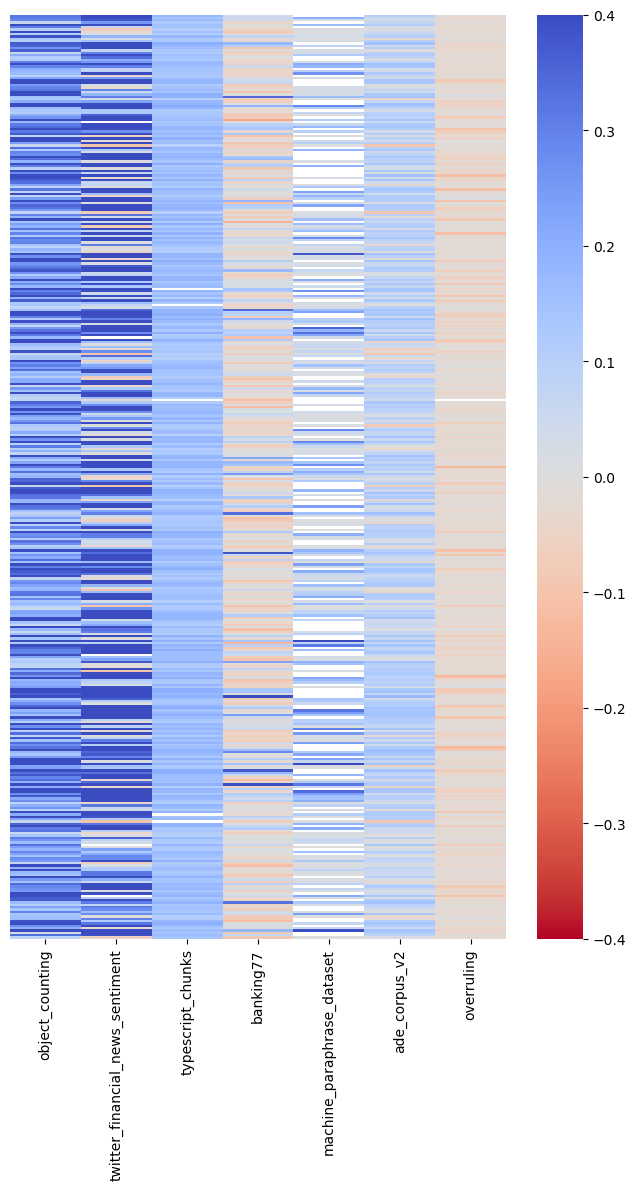

In [44]:
f, ax = plt.subplots(figsize=(8,12))
sns.heatmap(df_fin.sort_values('zero_shot')[[i for i in df_fin if i !='zero_shot']].T[check_tasks],
            cmap='coolwarm_r', annot=False, vmin=-0.4, vmax=0.4,
            ax=ax,
            yticklabels=False)

# The table shows that some tasks are harder to optimize with the given HF experts; some tasks are easier to optimize,
# and some have very few select models that can help; others mainly hurt or do not help.

In [45]:
df_fin.T.sort_values('banking77',ascending=False)[['banking77']].head(10)

,banking77
femT-data---llama-3.1-newformat-instruct,0.416300
femT-data---llama-3.1-Instruct-finetuned-NER,0.396477
chchen---Llama-3.1-8B-Instruct-PsyCourse-doc-info-fold3,0.383261
Boffl---BullingerLM-llama3.1-8B-instruct-qa,0.377754
chchen---Llama-3.1-8B-Instruct-PsyCourse-doc-info-fold8,0.345816
chchen---Llama-3.1-8B-Instruct-PsyCourse-doc-info-fold1,0.345816
chchen---Llama-3.1-8B-Instruct-PsyCourse-doc-info-fold5,0.335904
chchen---Llama-3.1-8B-Instruct-PsyCourse-doc-info-fold6,0.328195
zero_shot,0.294805
chchen---Llama-3.1-8B-Instruct-PsyCourse-doc-info-fold10,0.283040
